dict_keys(['__header__', '__version__', '__globals__', 'F1', 'u'])


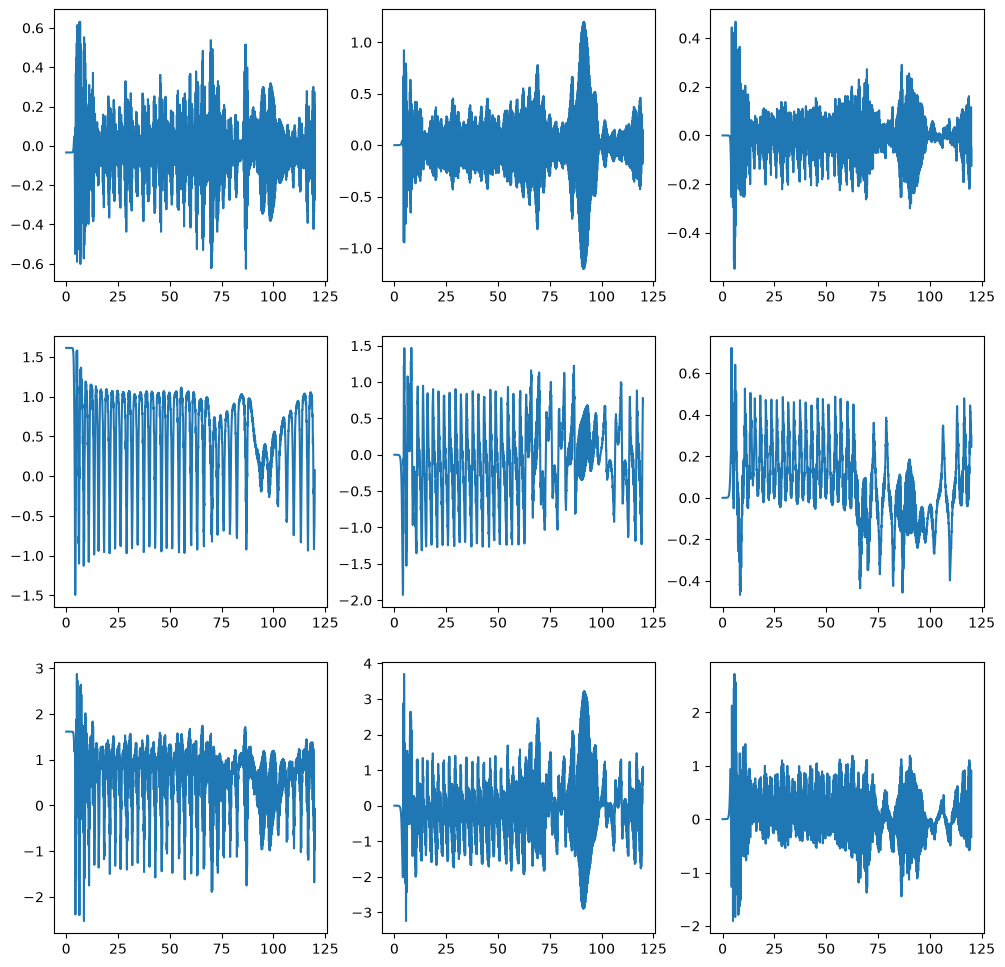

In [1]:
import scipy.io
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargar el archivo .mat
data = scipy.io.loadmat('data/NN_training_data.mat')
print(data.keys())

nt = data['u'].shape[1]
nT_train = 1344000
T_train = 700
dt = T_train / nT_train
t = np.linspace(0, int(nt * dt), nt)
X = data['u']

start_idx = int(0 / dt)
end_idx = int(120 / dt)

plt.figure(figsize=(12,12))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.plot(t[start_idx:end_idx], X[i][start_idx:end_idx])

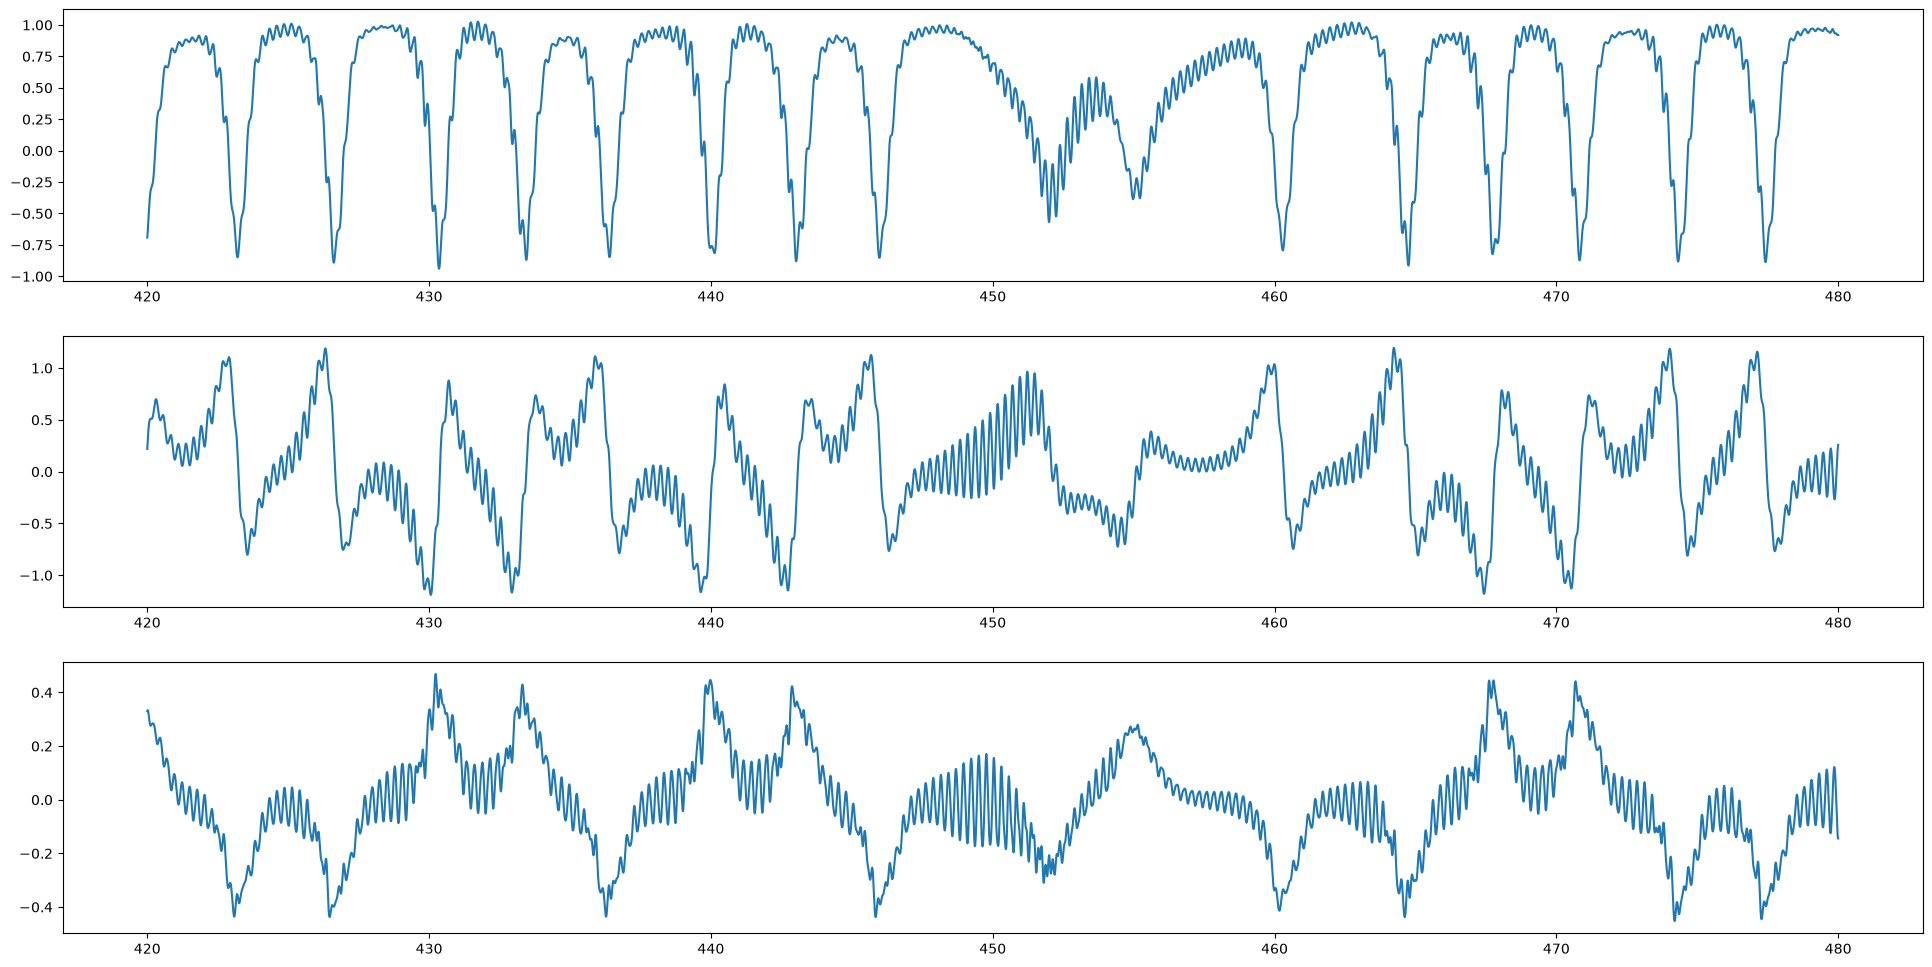

In [2]:
start_idx = int(420 / dt)
end_idx = int(480 / dt)

plt.figure(figsize=(24,12))
for i in range(3):
    plt.subplot(3,1,i+1)
    plt.plot(t[start_idx:end_idx], X[3+i][start_idx:end_idx])

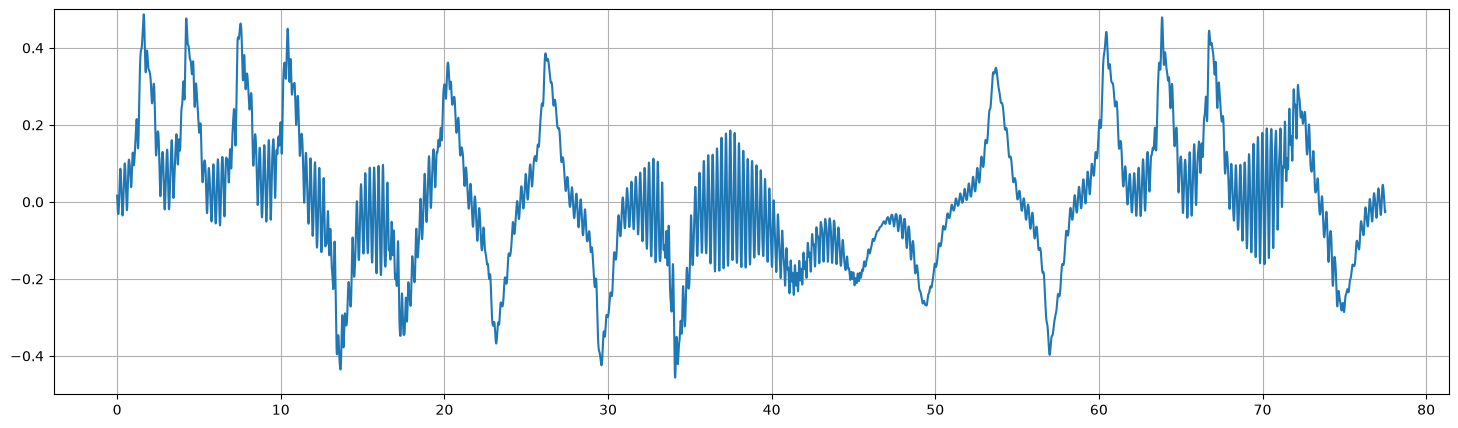

In [4]:
# COMPARE WITH FIGURE 2
plt.figure(figsize=(18,5))
#plt.plot(t[:100000], data['u'][3:6][-1][:100000])
start_idx = int( 425 / 4.2e-3)
end_idx = int( 1050 / 4.2e-3)
t -= t[start_idx]
plt.plot(t[start_idx:end_idx], data['u'][3:6][-1][start_idx:end_idx])
plt.ylim(-0.5, 0.5)
plt.grid()

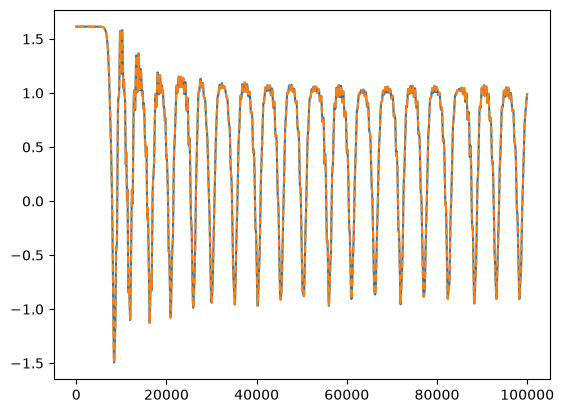

In [3]:
a1, a2, a3 = 1, 1, 3
v0 = 1 / 48
b1 = (a1 - a2 - a3) / 2
b2 = (a2 - a3 - a1) / 2
b3 = (a3 - a1 - a2) / 2
c = np.sqrt(b1 * b2 + b2 * b3 + b3 * b1)

def dYdt(x, y, z):
    x1, x2, x3 = x
    y1, y2, y3 = y
    z1, z2, z3 = z
    dy1dt = - a3 * b3 * x2 * y3 - a2 * b2 * y2 * x3 + c * (a3 - a2) * y2 * y3 - a1 * x1 - v0 * a1**2 * y1
    dy1dt /= a1
    dy2dt = - a1 * b1 * x3 * y1 - a3 * b3 * y3 * x1 + c * (a1 - a3) * y3 * y1 - a2 * x2 - v0 * a2**2 * y2
    dy2dt /= a2
    dy3dt = - a2 * b2 * x1 * y2 - a1 * b1 * y1 * x2 + c * (a2 - a1) * y1 * y2 - a3 * x3 - v0 * a3**2 * y3
    dy3dt /= a3
    return np.array([dy1dt, dy2dt, dy3dt])

def rk4_step_y(y, x, z, dt):
    k1 = dYdt(x, y, z)
    k2 = dYdt(x, y + 0.5 * dt * k1, z)
    k3 = dYdt(x, y + 0.5 * dt * k2, z)
    k4 = dYdt(x, y + dt * k3, z)
    return y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

X = data['u'][0:3]
Y = data['u'][3:6]
Z = data['u'][6:9]

start_idx = 0
Y_sim = np.zeros_like(Y)
Y_sim[:,0] = Y[:,start_idx]

for i in range(100000):
    #Y_sim[:,i+1] = rk4_step_y(Y_sim[:,i], X[:,start_idx+i], Z[:,start_idx+i], 4.2e-3)
    Y_sim[:,i+1] = rk4_step_y(Y[:,start_idx+i], X[:,start_idx+i], Z[:,start_idx+i], 4.2e-3)

plt.plot(Y[0][start_idx:start_idx+100000])
plt.plot(Y_sim[0][:100000], '--')